## Step 1: Initial Setup, Dataset Loading & Basic Checks
We start by setting up display preferences, loading the Tesla dataset from the directory path, and running preliminary structural and dimension verifications.

In [1]:
import pandas as pd
df=pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [2]:
print("=== DATA OVERVIEW & MISSING VALUES CHECK ===")
df.info()

print("\n=== STATISTICAL SUMMARY & OUTLIER CHECK ===")
df.describe()

=== DATA OVERVIEW & MISSING VALUES CHECK ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

=== STATISTICAL SUMMARY & OUTLIER CHECK ===


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Step 2: Exploratory Data Analysis (EDA) & Stationarity Testing
In this block, we analyze data distribution and detect outliers visually using boxplots and histograms. Since this is time-series data, we also apply an Augmented Dickey-Fuller (ADF) statistical test to verify if the series behaves stationary before modeling.

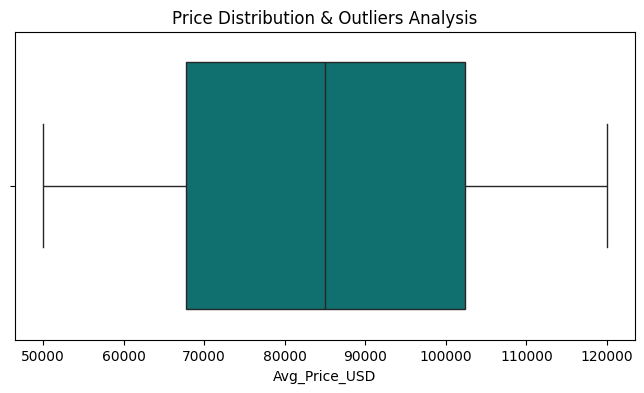

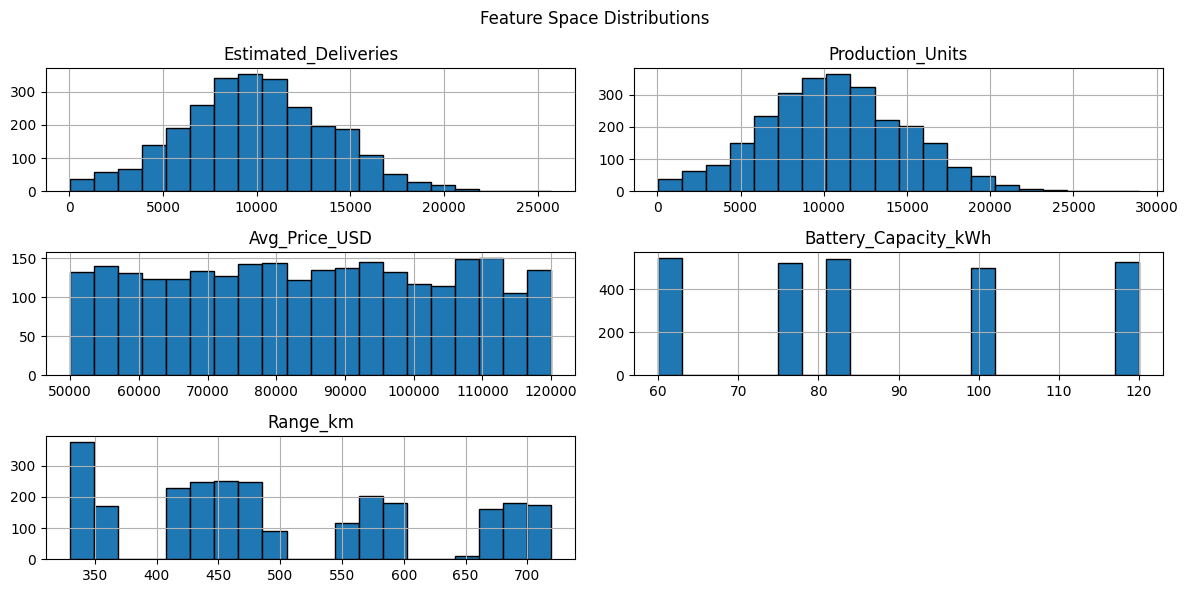


=== STATIONARITY STATUS (ADF TEST) ===
ADF Statistic: -8.880990349502973
ADF P-Value: 1.3181396968145779e-14


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 2.1 Outlier & Distribution Visual Checks
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Avg_Price_USD'], color='teal')
plt.title("Price Distribution & Outliers Analysis")
plt.show()

num_feats = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km']
df[num_feats].hist(bins=20, figsize=(12, 6), edgecolor='black')
plt.suptitle("Feature Space Distributions")
plt.tight_layout()
plt.show()

# 2.2 Time Series Grouping & Stationarity Test
ts_check = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].mean().reset_index()
ts_check = ts_check.sort_values(['Year', 'Month']).reset_index(drop=True)

adf_res = adfuller(ts_check['Estimated_Deliveries'])
print("\n=== STATIONARITY STATUS (ADF TEST) ===")
print("ADF Statistic:", adf_res[0])
print("ADF P-Value:", adf_res[1])
# A p-value below 0.05 indicates the structure is stable/stationary over time

## Step 3: Preprocessing & Time-Aware Feature Engineering
To preserve chronological order, we sort the dataset by Year and Month. We convert string flags using LabelEncoder and construct custom features like product efficiency ratios, lag points (Lag_1, Lag_2), and a moving rolling average. This gives our regression models temporal awareness.

In [4]:
from sklearn.preprocessing import LabelEncoder

# Enforcing chronological sort order across the dataframe
df_clean = df.copy()
df_clean = df_clean.sort_values(['Year', 'Month']).reset_index(drop=True)

# Processing categorical strings to structural codes
le = LabelEncoder()
df_clean['Region_enc'] = le.fit_transform(df_clean['Region'])
df_clean['Model_enc'] = le.fit_transform(df_clean['Model'])
df_clean['Source_enc'] = le.fit_transform(df_clean['Source_Type'])

# Generating efficiency ratios & time horizons
df_clean['Prod_Ratio'] = df_clean['Estimated_Deliveries'] / df_clean['Production_Units']
df_clean['Range_per_kwh'] = df_clean['Range_km'] / df_clean['Battery_Capacity_kWh']
df_clean['Quarter'] = ((df_clean['Month'] - 1) // 3) + 1

# Extracting past historical flags (Lags & Rolling Windows)
df_clean['Lag_1'] = df_clean['Estimated_Deliveries'].shift(1)
df_clean['Lag_2'] = df_clean['Estimated_Deliveries'].shift(2)
df_clean['Roll_Mean_3'] = df_clean['Estimated_Deliveries'].shift(1).rolling(window=3).mean()

# Dropping initial historical boundaries containing NaN elements
df_clean = df_clean.dropna().reset_index(drop=True)
print("Data shape after feature engineering:", df_clean.shape)

Data shape after feature engineering: (2637, 21)


## Step 4: Temporal Split Optimization & Scaling
We avoid standard randomized shuffling partitions to isolate future values cleanly and prevent structural data leakage. We execute a manual 80% training and 20% validation split based strictly on time index positions, followed by normalization scaling.

In [5]:
from sklearn.preprocessing import StandardScaler

# Mapping variables configuration match
final_features = ['Year', 'Month', 'Quarter', 'Region_enc', 'Model_enc', 'Source_enc',
                  'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
                  'CO2_Saved_tons', 'Charging_Stations', 'Prod_Ratio', 'Range_per_kwh',
                  'Lag_1', 'Lag_2', 'Roll_Mean_3']

X = df_clean[final_features]
y = df_clean['Estimated_Deliveries']

# Applying 80% split cut-off point manually
split_point = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# Normalization scaling matrix transformation
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

print("Split validation matrix established successfully.")
print("Train Matrix Shape:", X_train_sc.shape, "| Validation Test Matrix Shape:", X_test_sc.shape)

Split validation matrix established successfully.
Train Matrix Shape: (2109, 17) | Validation Test Matrix Shape: (528, 17)


## Step 5: Regularized Regression Baseline Evaluations
We train three fundamental linear model expressions to establish an operational baseline: standard Ordinary Least Squares (OLS) Linear Regression, Ridge Regression (L2 regularization), and Lasso Regression (L1 regularization). Performance is computed via MAE and R2 metrics.

In [6]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score

# Fit the three baseline algorithms
lr_base = LinearRegression().fit(X_train_sc, y_train)
ridge_base = Ridge(alpha=1.0).fit(X_train_sc, y_train)
lasso_base = Lasso(alpha=1.0).fit(X_train_sc, y_train)

print("=== LINEAR COMPILATION MEASURES ===")
for name, m in [("OLS Linear Regression", lr_base), ("Ridge (L2 Regularized)", ridge_base), ("Lasso (L1 Regularized)", lasso_base)]:
    test_preds = m.predict(X_test_sc)
    print(f"[{name}] MAE: {mean_absolute_error(y_test, test_preds):.2f} | R2 Score: {r2_score(y_test, test_preds):.4f}")

=== LINEAR COMPILATION MEASURES ===
[OLS Linear Regression] MAE: 106.31 | R2 Score: 0.9983
[Ridge (L2 Regularized)] MAE: 106.07 | R2 Score: 0.9983
[Lasso (L1 Regularized)] MAE: 106.88 | R2 Score: 0.9983


## Step 6: Hyperparameter Tuning via TimeSeriesSplit Validation
Instead of regular randomized K-Fold, we combine GridSearchCV with a strict TimeSeriesSplit framework. This guarantees that model validation sequences always train on past trends to evaluate future horizons, finding the optimal regularization alpha strength safely.

In [7]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Setting up structural search fields
param_search = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
time_cv = TimeSeriesSplit(n_splits=5)

# Hyperparameter search execution over linear weights
grid_search = GridSearchCV(Ridge(), param_search, cv=time_cv, scoring='r2')
grid_search.fit(X_train_sc, y_train)

print("Optimized Hyperparameter Selected (Best Alpha):", grid_search.best_params_)

# Validating best model metrics against our unseen split section
best_model = grid_search.best_estimator_
final_predictions = best_model.predict(X_test_sc)

print("\n=== FINAL CHRONOLOGICAL PERFORMANCE VALUES ===")
print("Final Test Evaluated MAE:", mean_absolute_error(y_test, final_predictions))
print("Final Test Evaluated R2 Score:", r2_score(y_test, final_predictions))

Optimized Hyperparameter Selected (Best Alpha): {'alpha': 0.01}

=== FINAL CHRONOLOGICAL PERFORMANCE VALUES ===
Final Test Evaluated MAE: 106.30818797516147
Final Test Evaluated R2 Score: 0.9982922014975171


## Step 7: Time Series Forecasting Pipeline Visualization
We chart the actual data stream side-by-side with our tuned regularized forecast curve. This layout allows for visual inspection of target adjustments across consecutive timeline evaluation horizons.

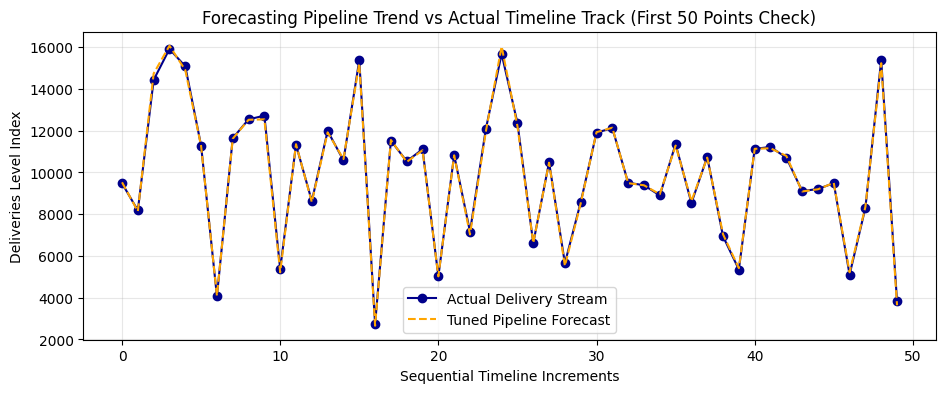

In [8]:
plt.figure(figsize=(11, 4))
plt.plot(y_test.values[:50], label='Actual Delivery Stream', color='darkblue', marker='o')
plt.plot(final_predictions[:50], label='Tuned Pipeline Forecast', color='orange', linestyle='--')
plt.title('Forecasting Pipeline Trend vs Actual Timeline Track (First 50 Points Check)')
plt.xlabel('Sequential Timeline Increments')
plt.ylabel('Deliveries Level Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()